In [2]:
import pandas as pd
import sqlalchemy
import psycopg2

# --- Database Connection Details ---
# Make sure your Docker container is running!
DB_NAME = "chris_db"
DB_USER = "postgres"
DB_PASSWORD = "password"  # The password you set in your docker run command
DB_HOST = "localhost"
DB_PORT = "5432"

# Create the database connection URL
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Create a SQLAlchemy engine
try:
    engine = sqlalchemy.create_engine(db_url)
    print("Successfully connected to the database!")
except Exception as e:
    print(f"Failed to connect to the database. Error: {e}")


# --- Read Data from the 'binance_trades' Table ---
table_name_trades = "binance_trades"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_trades = f"SELECT * FROM {table_name_trades} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_trades = pd.read_sql(query_trades, connection)
    
    print(f"\nSuccessfully loaded {len(df_trades)} rows from '{table_name_trades}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_trades.head()) 
    print(df_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_trades}'. Error: {e}")


# --- Read Data from the 'binance_orderbook_features' Table ---
table_name_ob = "binance_orderbook_features"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_ob = f"SELECT * FROM {table_name_ob} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_orderbook = pd.read_sql(query_ob, connection)
    
    print(f"\nSuccessfully loaded {len(df_orderbook)} rows from '{table_name_ob}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_orderbook.head())
    print(df_orderbook.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_ob}'. Error: {e}")


Successfully connected to the database!
Failed to read data from table 'binance_trades'. Error: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)
Failed to read data from table 'binance_orderbook_features'. Error: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at:

# orderbook aggregating

In [17]:
query_ob = """
SELECT
    FLOOR(timestamp_ms / 1000) * 1000 AS timestamp_ms_1s,
    AVG(bid_l1_price) AS bid_l1_price,
    AVG(bid_l1_cumulative_qty) AS bid_l1_cumulative_qty,
    AVG(ask_l1_price) AS ask_l1_price,
    AVG(ask_l1_cumulative_qty) AS ask_l1_cumulative_qty,
    AVG(ask_l20_price) AS ask_l20_price,
    AVG(ask_l20_cumulative_qty) AS ask_l20_cumulative_qty,
    AVG(bid_l20_price) AS bid_l20_price,
    AVG(bid_l20_cumulative_qty) AS bid_l20_cumulative_qty
FROM binance_orderbook_features
GROUP BY FLOOR(timestamp_ms / 1000)
ORDER BY timestamp_ms_1s DESC
"""

In [18]:
try:
    with engine.connect() as connection:
        df_orderbook_aggregated = pd.read_sql(query_ob, connection)

    print(f"\nSuccessfully loaded {len(df_orderbook_aggregated)} aggregated rows from '{table_name_ob}'.")
except Exception as e:
    print(f"Failed to read data from table '{table_name_ob}'. Error: {e}")

df_orderbook_aggregated.head()


Successfully loaded 429311 aggregated rows from 'binance_orderbook_features'.


,timestamp_ms_1s,bid_l1_price,bid_l1_cumulative_qty,ask_l1_price,ask_l1_cumulative_qty,ask_l20_price,ask_l20_cumulative_qty,bid_l20_price,bid_l20_cumulative_qty
0,1.750947e+12,107117.64,15.573000,107117.74,4.596000,107121.060000,5.805800,107114.020000,16.928000
1,1.750947e+12,107110.90,21.003667,107111.00,0.140111,107114.644444,0.345333,107108.133333,28.681333
2,1.750947e+12,107102.50,20.492222,107102.60,0.949222,107107.222222,3.786333,107098.966667,28.675667
3,1.750947e+12,107099.80,16.916857,107099.90,3.090857,107104.285714,9.047857,107096.171429,19.334857
4,1.750947e+12,107099.80,15.893200,107099.90,3.454600,107104.060000,9.313900,107096.100000,19.314400


# trades df

In [19]:
from sqlalchemy import text

query_trades_agg = text("""
SELECT
    FLOOR(timestamp_ms / 1000) * 1000 AS timestamp_ms_1s,
    SUM(sell_volume) AS sell_volume,
    SUM(buy_volume) AS buy_volume,
    SUM(total_volume) AS total_volume,
    SUM(total_trade_count) AS total_trade_count
FROM binance_trades
GROUP BY FLOOR(timestamp_ms / 1000)
ORDER BY timestamp_ms_1s DESC
""")

try:
    with engine.connect() as connection:
        df_trades_agg = pd.read_sql(query_trades_agg, connection)

    print(f"\nSuccessfully loaded {len(df_trades_agg)} aggregated rows from '{table_name_trades}'.")
except Exception as e:
    print(f"Failed to read aggregated data from table '{table_name_trades}'. Error: {e}")

df_trades_agg.head()


Successfully loaded 429311 aggregated rows from 'binance_trades'.


,timestamp_ms_1s,sell_volume,buy_volume,total_volume,total_trade_count
0,1.750947e+12,0.020,0.629,0.649,63.0
1,1.750947e+12,0.248,0.486,0.734,56.0
2,1.750947e+12,0.014,8.722,8.736,196.0
3,1.750947e+12,0.203,0.911,1.114,39.0
4,1.750947e+12,0.142,0.910,1.052,18.0


# now group

In [20]:
# Merge on timestamp_ms_1s with inner join to keep only matching rows
df_merged = pd.merge(
    df_trades_agg,
    df_orderbook_aggregated,
    on='timestamp_ms_1s',
    how='inner',
    suffixes=('_trades', '_orderbook')
)

print(f"Merged dataframe shape: {df_merged.shape}")

df_merged.info()

Merged dataframe shape: (429306, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429306 entries, 0 to 429305
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   timestamp_ms_1s         429306 non-null  float64
 1   sell_volume             429306 non-null  float64
 2   buy_volume              429306 non-null  float64
 3   total_volume            429306 non-null  float64
 4   total_trade_count       429306 non-null  float64
 5   bid_l1_price            429306 non-null  float64
 6   bid_l1_cumulative_qty   429306 non-null  float64
 7   ask_l1_price            429306 non-null  float64
 8   ask_l1_cumulative_qty   429306 non-null  float64
 9   ask_l20_price           429306 non-null  float64
 10  ask_l20_cumulative_qty  429306 non-null  float64
 11  bid_l20_price           429306 non-null  float64
 12  bid_l20_cumulative_qty  429306 non-null  float64
dtypes: float64(13)
memory usage: 42.6 MB


In [21]:
df_merged.head()

,timestamp_ms_1s,sell_volume,buy_volume,total_volume,total_trade_count,bid_l1_price,bid_l1_cumulative_qty,ask_l1_price,ask_l1_cumulative_qty,ask_l20_price,ask_l20_cumulative_qty,bid_l20_price,bid_l20_cumulative_qty
0,1.750947e+12,0.020,0.629,0.649,63.0,107117.64,15.573000,107117.74,4.596000,107121.060000,5.805800,107114.020000,16.928000
1,1.750947e+12,0.248,0.486,0.734,56.0,107110.90,21.003667,107111.00,0.140111,107114.644444,0.345333,107108.133333,28.681333
2,1.750947e+12,0.014,8.722,8.736,196.0,107102.50,20.492222,107102.60,0.949222,107107.222222,3.786333,107098.966667,28.675667
3,1.750947e+12,0.203,0.911,1.114,39.0,107099.80,16.916857,107099.90,3.090857,107104.285714,9.047857,107096.171429,19.334857
4,1.750947e+12,0.142,0.910,1.052,18.0,107099.80,15.893200,107099.90,3.454600,107104.060000,9.313900,107096.100000,19.314400


In [22]:
import matplotlib.pyplot as plt

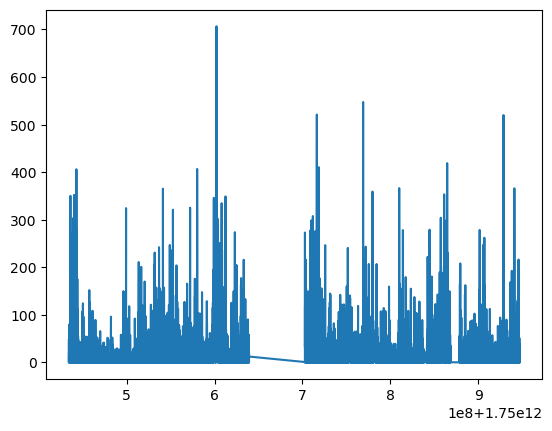

In [23]:
plt.plot(df_trades_agg['timestamp_ms_1s'], df_trades_agg['total_volume'])

In [24]:
import numpy as np

# Assume your merged df is sorted by timestamp_ms_1s ascending
df_merged = df_merged.sort_values('timestamp_ms_1s').reset_index(drop=True)

# Calculate the difference between consecutive timestamps
df_merged['time_diff'] = df_merged['timestamp_ms_1s'].diff()

# Identify where the gap is > 1000 ms (1 second)
new_group = df_merged['time_diff'] > 10000

# Create a group ID that increments whenever a gap > 1s is found
df_merged['group_id'] = new_group.cumsum()

# Split the dataframe into a list of dataframes by group_id
list_of_dfs = [group_df.drop(columns=['time_diff', 'group_id']) for _, group_df in df_merged.groupby('group_id')]

# Print lengths of each chunk
for i, chunk_df in enumerate(list_of_dfs):
    print(f"Chunk {i} length: {len(chunk_df)}")


Chunk 0 length: 15198
Chunk 1 length: 67278
Chunk 2 length: 1415
Chunk 3 length: 29908
Chunk 4 length: 1314
Chunk 5 length: 32980
Chunk 6 length: 16540
Chunk 7 length: 13179
Chunk 8 length: 26180
Chunk 9 length: 6919
Chunk 10 length: 9144
Chunk 11 length: 47
Chunk 12 length: 1989
Chunk 13 length: 7093
Chunk 14 length: 24196
Chunk 15 length: 2832
Chunk 16 length: 3
Chunk 17 length: 23015
Chunk 18 length: 55201
Chunk 19 length: 17421
Chunk 20 length: 8501
Chunk 21 length: 68953


In [25]:
largest_chunk = list_of_dfs[21]

# sort by timestamp descending
largest_chunk = largest_chunk.sort_values('timestamp_ms_1s', ascending=False)

largest_chunk.head()

,timestamp_ms_1s,sell_volume,buy_volume,total_volume,total_trade_count,bid_l1_price,bid_l1_cumulative_qty,ask_l1_price,ask_l1_cumulative_qty,ask_l20_price,ask_l20_cumulative_qty,bid_l20_price,bid_l20_cumulative_qty
429305,1.750947e+12,0.020,0.629,0.649,63.0,107117.64,15.573000,107117.74,4.596000,107121.060000,5.805800,107114.020000,16.928000
429304,1.750947e+12,0.248,0.486,0.734,56.0,107110.90,21.003667,107111.00,0.140111,107114.644444,0.345333,107108.133333,28.681333
429303,1.750947e+12,0.014,8.722,8.736,196.0,107102.50,20.492222,107102.60,0.949222,107107.222222,3.786333,107098.966667,28.675667
429302,1.750947e+12,0.203,0.911,1.114,39.0,107099.80,16.916857,107099.90,3.090857,107104.285714,9.047857,107096.171429,19.334857
429301,1.750947e+12,0.142,0.910,1.052,18.0,107099.80,15.893200,107099.90,3.454600,107104.060000,9.313900,107096.100000,19.314400


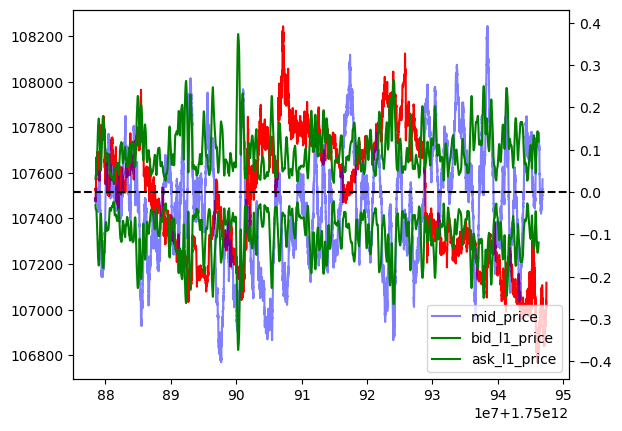

In [26]:
largest_chunk['mid_price'] = (largest_chunk['bid_l1_price'] + largest_chunk['ask_l1_price']) / 2
largest_chunk['spread'] = largest_chunk['ask_l1_price'] - largest_chunk['bid_l1_price']

largest_chunk['buy_ratio'] = np.where(
    largest_chunk['total_volume'] == 0,
    0,
    (largest_chunk['buy_volume'] / largest_chunk['total_volume']) * 2 - 1
)

largest_chunk['buy_ratio_scaled'] = largest_chunk['buy_ratio'] * np.log10(1 + largest_chunk['total_volume'])
# rolling window on buy ratio scaled
largest_chunk['buy_ratio_scaled_rolling'] = largest_chunk['buy_ratio_scaled'].rolling(window=60).mean()
largest_chunk['buy_ratio_rolling'] = largest_chunk['buy_ratio'].rolling(window=600).mean()
largest_chunk['buy_ratio_rolling_std'] = largest_chunk['buy_ratio_rolling'].rolling(window=600).std()

plt.plot(largest_chunk['timestamp_ms_1s'], largest_chunk['mid_price'], c='red')
plt.twinx()

plt.plot(largest_chunk['timestamp_ms_1s'], largest_chunk['buy_ratio_rolling'], color='blue', alpha=0.5)
plt.plot(largest_chunk['timestamp_ms_1s'], largest_chunk['buy_ratio_rolling_std']*2, color='green', alpha=1.0)
plt.plot(largest_chunk['timestamp_ms_1s'], -largest_chunk['buy_ratio_rolling_std']*2, color='green', alpha=1.0)


plt.axhline(y=0, color='black', linestyle='--')

plt.legend(['mid_price', 'bid_l1_price', 'ask_l1_price'])
plt.show()

Price Movement:  84.15645067501298


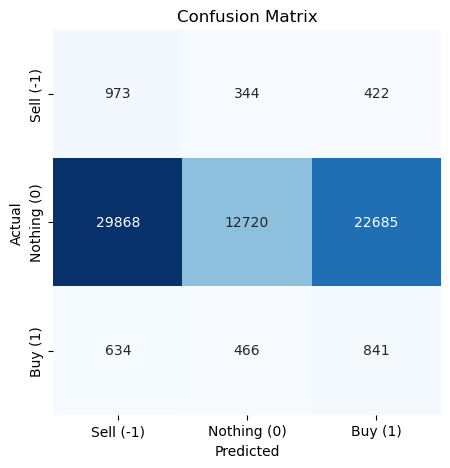

In [29]:
copy = largest_chunk.copy()

std_thresh = 1

price_window = 60
indicator_window = 120

price_std_thres = 2

copy['buy_ratio_rolling'] = copy['buy_ratio'].rolling(window=indicator_window).mean()

copy['buy_indicator'] = np.where(copy['buy_ratio_rolling'] > copy['buy_ratio_rolling_std']*std_thresh, 1, 0)
copy['sell_indicator'] = np.where(copy['buy_ratio_rolling'] < -copy['buy_ratio_rolling_std']*std_thresh, -1, 0)

copy['signal_indicator'] = copy['buy_indicator'] + copy['sell_indicator']
copy['delta'] = copy['mid_price'].shift(-price_window) - copy['mid_price']

print(f"Trying to classify Price Movement of ${copy['delta'].std()*price_std_thres:.2f} in either direction.")
print(f"Using a rolling mean of last {indicator_window} seconds on buy ratio to predict the next {price_window} seconds.")
print(f"Buy signal means price went up in the next {price_window} seconds.")
print(f"Sell signal means price went down in the next {price_window} seconds.")

copy['true_sell_signal'] = np.where(copy['delta'] < -copy['delta'].std()*price_std_thres, 1, 0)
copy['true_buy_signal'] = np.where(copy['delta'] > copy['delta'].std()*price_std_thres, -1, 0)

copy['true_signal'] = copy['true_sell_signal'] + copy['true_buy_signal']


y_pred = copy['signal_indicator']
y_true = copy['true_signal']


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Note: For multi-class, average='macro' or 'weighted' works better
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)


cm = confusion_matrix(y_true, y_pred, labels=[-1,0,1])
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sell (-1)', 'Nothing (0)', 'Buy (1)'],
            yticklabels=['Sell (-1)', 'Nothing (0)', 'Buy (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [243]:
sells = 667
nothings = 8759
buys = 2000

price_movement = 41.697

total = sells + nothings + buys
something_happens = sells + buys

print(f"Time nothing happens: {nothings/total*100:.2f}%")
print(f"Time something happens: {something_happens/total*100:.2f}%")

print("\n")

print(f"True buys when something happens: {buys/something_happens*100:.2f}%")
print(f"True sells when something happens: {sells/something_happens*100:.2f}%")

buy_edge = price_movement * (buys/something_happens)
sell_edge = -price_movement * (sells/something_happens)

print(f"Edge when something happens: {buy_edge:.2f}")
print(f"Edge: {(buy_edge + sell_edge)*(something_happens/total):.2f}")

Time nothing happens: 76.66%
Time something happens: 23.34%


True buys when something happens: 74.99%
True sells when something happens: 25.01%
Edge when something happens: 31.27
Edge: 4.86


mean of 1 minute price delta:  2.9968766731103966
std dev of 1 minute price delta:  114.53525067657633


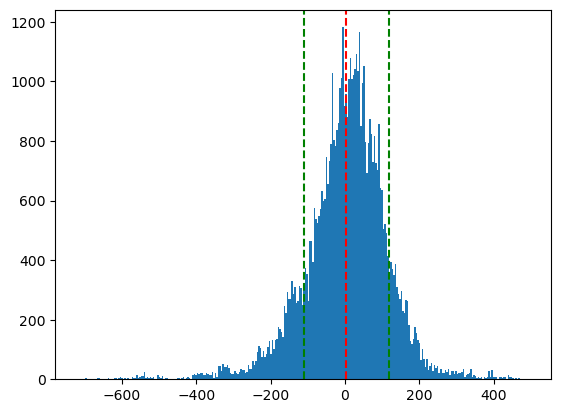

In [167]:
largest_chunk['1_minute_price_delta'] = largest_chunk['mid_price'].shift(-600) - largest_chunk['mid_price']

mean = largest_chunk['1_minute_price_delta'].mean()
std_dev = largest_chunk['1_minute_price_delta'].std()

print("mean of 1 minute price delta: ", mean)
print("std dev of 1 minute price delta: ", std_dev)

plt.figure()
plt.hist(largest_chunk['1_minute_price_delta'], bins=300)
plt.axvline(x=mean, color='red', linestyle='--')
plt.axvline(x=mean + std_dev, color='green', linestyle='--')
plt.axvline(x=mean - std_dev, color='green', linestyle='--')

largest_chunk['sell_signal'] = np.where(largest_chunk['1_minute_price_delta'] < -std_dev, -1, 0)
largest_chunk['buy_signal'] = np.where(largest_chunk['1_minute_price_delta'] > std_dev, 1, 0)

In [175]:
signal = 'buy_ratio' # 'buy_ratio' or 'buy_ratio_scaled'
lookback = 600 # lookback and look forward

df_eval = largest_chunk.copy()

df_eval['indicator'] = df_eval[signal].rolling(window=lookback).mean()

df_eval['signal'] = df_eval['mid_price'].shift(-lookback) - df_eval['mid_price']
std = df_eval['signal'].std()

df_eval['sell_signal'] = np.where(df_eval['signal'] < -std, -1, 0)
df_eval['buy_signal'] = np.where(df_eval['signal'] > std, 1, 0)

df_eval.dropna(subset=['buy_signal', 'sell_signal', 'indicator'], inplace=True)

indicator_std = df_eval['indicator'].std()
thresholds = [indicator_std, indicator_std*2, indicator_std*3, indicator_std*4, indicator_std*5]

BUY STATS
roc_auc_buy: 0.514, prec_buy: 0.145, rec_buy: 0.159, f1_buy: 0.152
SELL STATS
roc_auc_sell: 0.489, prec_sell: 0.173, rec_sell: 0.193, f1_sell: 0.182
Threshold: 0.13644780132404546, Accuracy: 0.616, Precision: 0.369, Recall: 0.371, F1 Score: 0.369


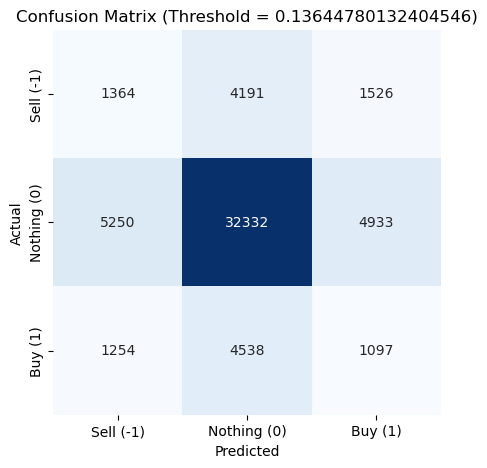

BUY STATS
roc_auc_buy: 0.514, prec_buy: 0.148, rec_buy: 0.099, f1_buy: 0.118
SELL STATS
roc_auc_sell: 0.489, prec_sell: 0.181, rec_sell: 0.120, f1_sell: 0.144
Threshold: 0.27289560264809093, Accuracy: 0.674, Precision: 0.368, Recall: 0.359, F1 Score: 0.359


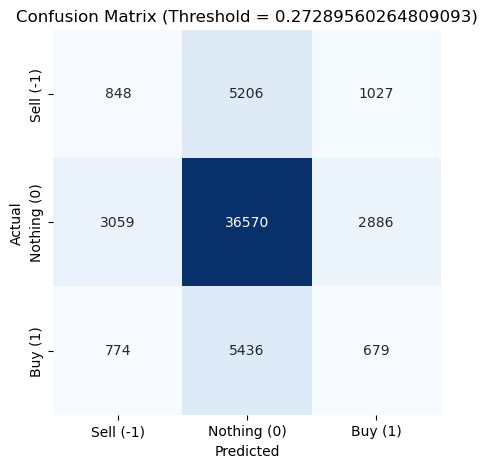

BUY STATS
roc_auc_buy: 0.514, prec_buy: 0.152, rec_buy: 0.066, f1_buy: 0.092
SELL STATS
roc_auc_sell: 0.489, prec_sell: 0.187, rec_sell: 0.078, f1_sell: 0.110
Threshold: 0.4093434039721364, Accuracy: 0.705, Precision: 0.369, Recall: 0.352, F1 Score: 0.346


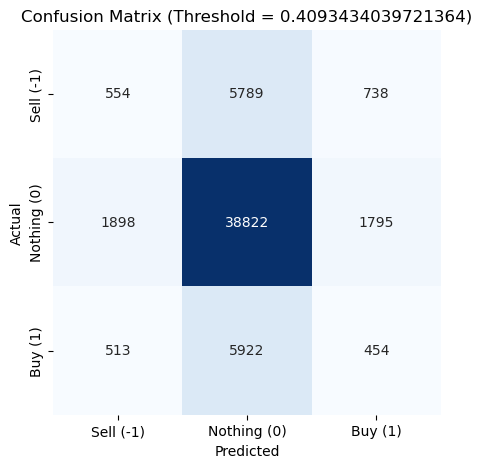

BUY STATS
roc_auc_buy: 0.514, prec_buy: 0.149, rec_buy: 0.043, f1_buy: 0.067
SELL STATS
roc_auc_sell: 0.489, prec_sell: 0.186, rec_sell: 0.050, f1_sell: 0.079
Threshold: 0.5457912052961819, Accuracy: 0.722, Precision: 0.366, Recall: 0.346, F1 Score: 0.330


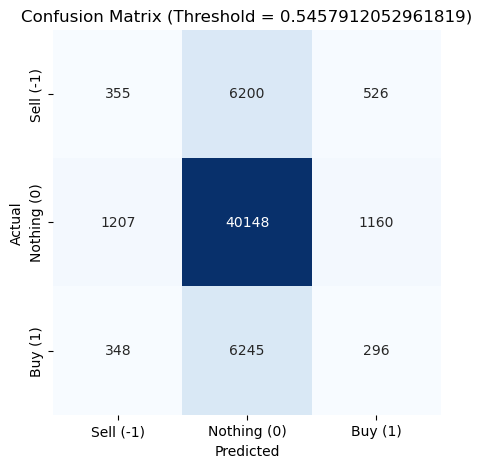

BUY STATS
roc_auc_buy: 0.514, prec_buy: 0.138, rec_buy: 0.026, f1_buy: 0.044
SELL STATS
roc_auc_sell: 0.489, prec_sell: 0.181, rec_sell: 0.032, f1_sell: 0.054
Threshold: 0.6822390066202273, Accuracy: 0.733, Precision: 0.360, Recall: 0.341, F1 Score: 0.316


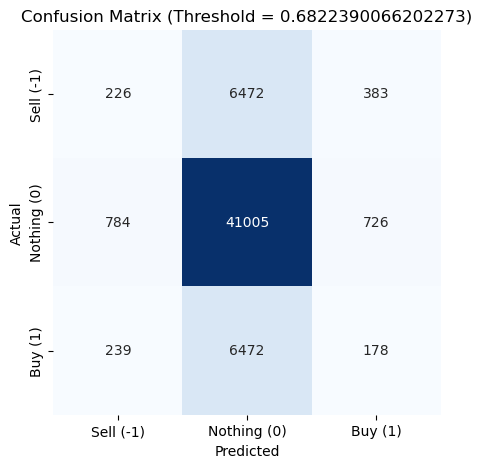

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Make sure your target variable exists

y_true = df_eval['buy_signal'] + df_eval['sell_signal']

# Define thresholds (use positive values, we'll use symmetric negative as well)
def three_class_predict(signal, thr):
    """
    Predict 3 classes:
    1 if signal > thr
    -1 if signal < -thr
    0 otherwise
    """
    pred = np.zeros(len(signal), dtype=int)
    pred[signal > thr] = 1
    pred[signal < -thr] = -1
    return pred

for thr in thresholds:
    y_pred = three_class_predict(df_eval['buy_ratio_scaled'], abs(thr))

    # Note: For multi-class, average='macro' or 'weighted' works better
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # Buy class (1) vs rest
    y_true_buy = (y_true == 1).astype(int)
    y_score_buy = df_eval['buy_ratio_scaled_rolling']
    y_pred_buy = (y_pred == 1).astype(int)
    try:
        roc_auc_buy = roc_auc_score(y_true_buy, y_score_buy)
        prec_buy = precision_score(y_true_buy, y_pred_buy, zero_division=0)
        rec_buy = recall_score(y_true_buy, y_pred_buy, zero_division=0)
        f1_buy = f1_score(y_true_buy, y_pred_buy, zero_division=0)

        print("BUY STATS")
        print(f"roc_auc_buy: {roc_auc_buy:.3f}, prec_buy: {prec_buy:.3f}, rec_buy: {rec_buy:.3f}, f1_buy: {f1_buy:.3f}")

    except ValueError as e:
        roc_auc_buy = prec_buy = rec_buy = f1_buy = np.nan
        print(f"[Warning] Buy ROC AUC skipped at threshold {thr}: {e}")

    # Sell class (-1) vs rest
    y_true_sell = (y_true == -1).astype(int)
    y_score_sell = -df_eval['buy_ratio_scaled_rolling']
    y_pred_sell = (y_pred == -1).astype(int)
    try:
        roc_auc_sell = roc_auc_score(y_true_sell, y_score_sell)
        prec_sell = precision_score(y_true_sell, y_pred_sell, zero_division=0)
        rec_sell = recall_score(y_true_sell, y_pred_sell, zero_division=0)
        f1_sell = f1_score(y_true_sell, y_pred_sell, zero_division=0)

        print("SELL STATS")
        print(f"roc_auc_sell: {roc_auc_sell:.3f}, prec_sell: {prec_sell:.3f}, rec_sell: {rec_sell:.3f}, f1_sell: {f1_sell:.3f}")

    except ValueError as e:
        roc_auc_sell = prec_sell = rec_sell = f1_sell = np.nan
        print(f"[Warning] Sell ROC AUC skipped at threshold {thr}: {e}")

    print(f"Threshold: {abs(thr)}, Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1 Score: {f1:.3f}")

    cm = confusion_matrix(y_true, y_pred, labels=[-1,0,1])
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Sell (-1)', 'Nothing (0)', 'Buy (1)'],
                yticklabels=['Sell (-1)', 'Nothing (0)', 'Buy (1)'])
    plt.title(f'Confusion Matrix (Threshold = {abs(thr)})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
query_ob = """
SELECT
    FLOOR(timestamp_ms / 1000) * 1000 AS timestamp_ms_1s,
    AVG(bid_l1_price) AS bid_l1_price,
    AVG(bid_l1_cumulative_qty) AS bid_l1_cumulative_qty,
    AVG(bid_l1_weighted_price) AS bid_l1_weighted_price,
    AVG(ask_l1_price) AS ask_l1_price,
    AVG(ask_l1_cumulative_qty) AS ask_l1_cumulative_qty,
    AVG(ask_l1_weighted_price) AS ask_l1_weighted_price,
    AVG(bid_l5_price) AS bid_l5_price,
    AVG(bid_l5_cumulative_qty) AS bid_l5_cumulative_qty,
    AVG(bid_l5_weighted_price) AS bid_l5_weighted_price,
    AVG(ask_l5_price) AS ask_l5_price,
    AVG(ask_l5_cumulative_qty) AS ask_l5_cumulative_qty,
    AVG(ask_l5_weighted_price) AS ask_l5_weighted_price,
    AVG(bid_l10_price) AS bid_l10_price,
    AVG(bid_l10_cumulative_qty) AS bid_l10_cumulative_qty,
    AVG(bid_l10_weighted_price) AS bid_l10_weighted_price,
    AVG(ask_l10_price) AS ask_l10_price,
    AVG(ask_l10_cumulative_qty) AS ask_l10_cumulative_qty,
    AVG(ask_l10_weighted_price) AS ask_l10_weighted_price,
    AVG(bid_l20_price) AS bid_l20_price,
    AVG(bid_l20_cumulative_qty) AS bid_l20_cumulative_qty,
    AVG(bid_l20_weighted_price) AS bid_l20_weighted_price,
    AVG(ask_l20_price) AS ask_l20_price,
    AVG(ask_l20_cumulative_qty) AS ask_l20_cumulative_qty,
    AVG(ask_l20_weighted_price) AS ask_l20_weighted_price
FROM binance_orderbook_features
GROUP BY FLOOR(timestamp_ms / 1000)
ORDER BY timestamp_ms_1s DESC
LIMIT 100000;
"""

